# Libraries

In [19]:
import pandas as pd
pd.set_option('display.max_columns', None)
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

# Read dataset

### Excel

In [20]:
filename_excel = '../dataset/dataset_1_rv3.xlsx'

In [21]:
df = pd.read_excel(filename_excel)
colunas_manter = [
                    'Diâmetro da armadura (mm)', 'Resistência do aço - fy (MPa)',
                    'Número de barras em uma camada', 'Espaçamento entre as barras (mm)',
                    'Resistência à tração do concreto (MPa)', 'Cobrimento (mm)',
                    'Distância ao centro de gravidade da armadura  (mm)',
                    'Largura da viga - b (mm)', 'Altura da viga - h (mm)',
                    'Área de aço tracionada - As (mm2)', 'Momento fletor - Ms (kNm)',
                    'Output: w_exp (mm)'
                 ]
df_filtrado = df[colunas_manter]
df_filtrado

,Diâmetro da armadura (mm),Resistência do aço - fy (MPa),Número de barras em uma camada,Espaçamento entre as barras (mm),Resistência à tração do concreto (MPa),Cobrimento (mm),Distância ao centro de gravidade da armadura (mm),Largura da viga - b (mm),Altura da viga - h (mm),Área de aço tracionada - As (mm2),Momento fletor - Ms (kNm),Output: w_exp (mm)
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,20.800,0.16
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,27.300,0.23
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,28.200,0.24
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,32.600,0.27
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,41.200,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...
336,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,149.268,0.19
337,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,168.882,0.22
338,35.8,276,2,36.4,2.547836,38.0,55.9,152.4,584.2,2012.0,167.034,0.17
339,35.8,276,2,36.4,2.756373,38.0,55.9,152.4,584.2,2012.0,130.788,0.19


In [22]:
df_filtrado.to_excel('crack_dataset_1.xlsx', index=False)

In [23]:
df_filtrado.columns

Index(['Diâmetro da armadura (mm)', 'Resistência do aço - fy (MPa)',
       'Número de barras em uma camada', 'Espaçamento entre as barras (mm)',
       'Resistência à tração do concreto (MPa)', 'Cobrimento (mm)',
       'Distância ao centro de gravidade da armadura  (mm)',
       'Largura da viga - b (mm)', 'Altura da viga - h (mm)',
       'Área de aço tracionada - As (mm2)', 'Momento fletor - Ms (kNm)',
       'Output: w_exp (mm)'],
      dtype='object')

In [24]:
x = df_filtrado[colunas_manter[:-1]]
x

,Diâmetro da armadura (mm),Resistência do aço - fy (MPa),Número de barras em uma camada,Espaçamento entre as barras (mm),Resistência à tração do concreto (MPa),Cobrimento (mm),Distância ao centro de gravidade da armadura (mm),Largura da viga - b (mm),Altura da viga - h (mm),Área de aço tracionada - As (mm2),Momento fletor - Ms (kNm)
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,20.800
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,27.300
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,28.200
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,32.600
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,41.200
...,...,...,...,...,...,...,...,...,...,...,...
336,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,149.268
337,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,168.882
338,35.8,276,2,36.4,2.547836,38.0,55.9,152.4,584.2,2012.0,167.034
339,35.8,276,2,36.4,2.756373,38.0,55.9,152.4,584.2,2012.0,130.788


In [25]:
y = df_filtrado[['Output: w_exp (mm)']]
y

,Output: w_exp (mm)
0,0.16
1,0.23
2,0.24
3,0.27
4,0.35
...,...
336,0.19
337,0.22
338,0.17
339,0.19


### Divided in three groups

In [26]:
y = y.squeeze()
y_class = pd.qcut(y, q=3, labels=["low", "medium", "high"])
df_labels = pd.DataFrame({"w": y, "class_w": y_class})
df_labels.head()

,w,class_w
0,0.16,low
1,0.23,medium
2,0.24,medium
3,0.27,medium
4,0.35,high


### Count the groups

In [27]:
df_labels["class_w"].value_counts()

class_w
low       139
high      107
medium     95
Name: count, dtype: int64

### Crack width classification

In [28]:
low = df_labels[df_labels["class_w"] == "low"]
medium = df_labels[df_labels["class_w"] == "medium"]
high = df_labels[df_labels["class_w"] == "high"]

In [29]:
low.describe()
text_low = rf"$w_{{min}}$: {low['w'].min():.2f}, $w_{{max}}$: {low['w'].max():.2f}"
text_low

'$w_{min}$: 0.14, $w_{max}$: 0.20'

In [30]:
medium.describe()
text_medium = rf"$w_{{min}}$: {medium['w'].min():.2f}, $w_{{max}}$: {medium['w'].max():.2f}"
text_medium

'$w_{min}$: 0.21, $w_{max}$: 0.27'

In [31]:
high.describe()
text_high = rf"$w_{{min}}$: {high['w'].min():.2f}, $w_{{max}}$: {high['w'].max():.2f}"
text_high

'$w_{min}$: 0.28, $w_{max}$: 0.79'

# Run TSNE ML

In [32]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
tsne = TSNE(
                n_components=2,
                perplexity=30,
                learning_rate="auto",
                init="pca",
                random_state=42
            )

x_tsne = tsne.fit_transform(x_scaled)
tsne_df = pd.DataFrame(
                            x_tsne,
                            columns=["tSNE1", "tSNE2"],
                            index=x.index
                       )

tsne_df["class_crack"] = y_class.values
tsne_df

,tSNE1,tSNE2,class_crack
0,-0.301644,-14.233129,low
1,-0.301073,-14.232739,medium
2,-0.300892,-14.232735,medium
3,-0.300222,-14.232408,medium
4,-0.298372,-14.232038,high
...,...,...,...
336,10.151402,10.060824,low
337,10.004324,10.074283,medium
338,9.879817,10.973238,low
339,9.965840,11.028919,low


In [33]:
tsne_df.loc[tsne_df["class_crack"] == "low", "class_w"] = text_low
tsne_df.loc[tsne_df["class_crack"] == "medium", "class_w"] = text_medium
tsne_df.loc[tsne_df["class_crack"] == "high", "class_w"] = text_high
tsne_df

,tSNE1,tSNE2,class_crack,class_w
0,-0.301644,-14.233129,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
1,-0.301073,-14.232739,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
2,-0.300892,-14.232735,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
3,-0.300222,-14.232408,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
4,-0.298372,-14.232038,high,"$w_{min}$: 0.28, $w_{max}$: 0.79"
...,...,...,...,...
336,10.151402,10.060824,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
337,10.004324,10.074283,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
338,9.879817,10.973238,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
339,9.965840,11.028919,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"


In [34]:
tsne_df.to_excel('TSNE_dataset_1.xlsx', index=False)  

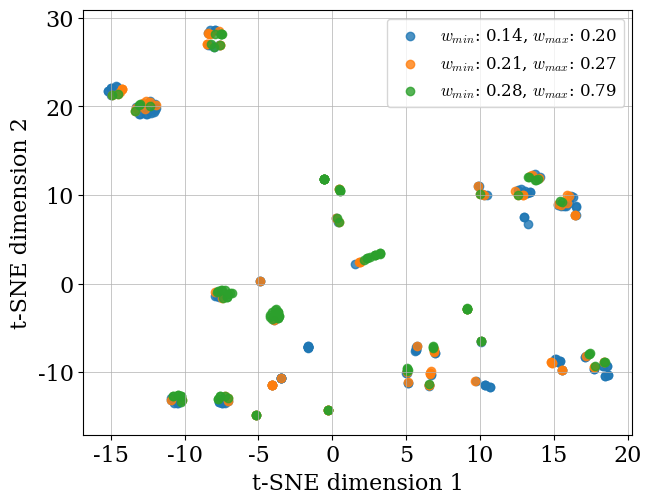

In [35]:
dpi = 600               # Change as you wish
name = 'TSNE_dataset_1' # Change as you wish

b_cm = 18                       # Change as you wish
h_cm = 14                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm


label_x = 't-SNE dimension 1' # Change as you wish
label_y = 't-SNE dimension 2'     # Change as you wish
size_label = 16                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 16                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

for classe in tsne_df["class_w"].unique():
    subset = tsne_df[tsne_df["class_w"] == classe]
    ax.scatter(
        subset["tSNE1"],
        subset["tSNE2"],
        label=classe,
        alpha=0.8
    )
    ax.legend(fontsize=12, loc='upper right')
# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [36]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(x_tsne, y_class)
sil

-0.015750618651509285